In [1]:
#Il primo passo è caricare il dataset e pre-elaborare i dati.
import pandas as pd
df = pd.read_csv("spettacolli.csv")
print(df)

    Age  Experience  Rank Nationality   Go
0    36          10     9          UK  YES
1    42          12     4         USA   NO
2    28           5     6           N  YES
3    55          20     8          UK  YES
4    30           7     5         USA   NO
5    48          15     7          UK  YES
6    22           3     3           N   NO
7    60          25     9         USA  YES
8    35           8     6          UK   NO
9    40          11     7         USA  YES
10   29           6     5           N  YES
11   50          18     8          UK  YES
12   25           4     4         USA   NO


In [2]:
#Gli alberi decisionali, come la maggior parte degli algoritmi 
#di ML, lavorano meglio con dati numerici. Le colonne 
#'Nationality' (Nazionalità) e 'Go' (Presenza) sono categoriche 
#e vengono mappate a valori numerici.
d = {'UK': 0, 'USA': 1, 'N': 2}
df['Nationality'] = df['Nationality'].map(d)
d = {'YES': 1, 'NO': 0}
df['Go'] = df['Go'].map(d)
print(df)

    Age  Experience  Rank  Nationality  Go
0    36          10     9            0   1
1    42          12     4            1   0
2    28           5     6            2   1
3    55          20     8            0   1
4    30           7     5            1   0
5    48          15     7            0   1
6    22           3     3            2   0
7    60          25     9            1   1
8    35           8     6            0   0
9    40          11     7            1   1
10   29           6     5            2   1
11   50          18     8            0   1
12   25           4     4            1   0


In [3]:
#Si definiscono le colonne delle caratteristiche (features) 
#che verranno utilizzate per fare previsioni e la colonna 
#target (y) che è il valore che si vuole prevedere.
features = ['Age', 'Experience', 'Rank', 'Nationality']
X = df[features]
y = df['Go']
print('colonne della features: ',X)
print("-" * 40)
print('colonne del target: ',y)

colonne della features:      Age  Experience  Rank  Nationality
0    36          10     9            0
1    42          12     4            1
2    28           5     6            2
3    55          20     8            0
4    30           7     5            1
5    48          15     7            0
6    22           3     3            2
7    60          25     9            1
8    35           8     6            0
9    40          11     7            1
10   29           6     5            2
11   50          18     8            0
12   25           4     4            1
----------------------------------------
colonne del target:  0     1
1     0
2     1
3     1
4     0
5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
Name: Go, dtype: int64


In [4]:
from matplotlib import pyplot as plt
import numpy as np


def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

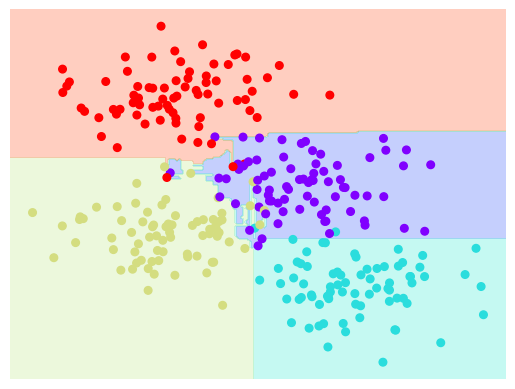

In [14]:
#Questo tipo di classificazione del bagging può essere eseguita 
#manualmente utilizzando il meta-stimatore BaggingClassifier di 
#Scikit-Learn:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=100, max_samples=0.8,
                        random_state=1)

bag.fit(X, y)
visualize_classifier(bag, X, y) 

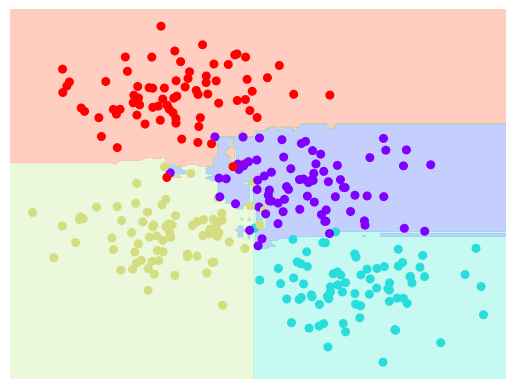

In [13]:
#In Scikit-Learn, un insieme ottimizzato di alberi decisionali 
#randomizzati è implementato nello stimatore 
#RandomForestClassifier, che si occupa automaticamente di tutta 
#la randomizzazione. Tutto quello che dobbiamo fare è selezionare 
#un numero di stimatori e molto rapidamente 
#(in parallelo, se lo desideriamo) adatterà l'insieme di alberi:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
visualize_classifier(model, X, y) 

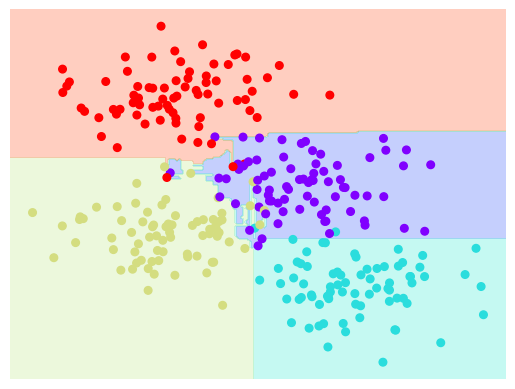

In [9]:
#Il bagging (Bootstrap Aggregating) è una tecnica di 
#ensemble che addestra più modelli sullo stesso algoritmo, 
#ma su sottoinsiemi casuali dei dati di training. 
#Il BaggingClassifier di Scikit-Learn implementa questo 
#approccio.
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree_bag = DecisionTreeClassifier()
# 100 alberi, ciascuno addestrato su l'80% dei campioni
bag = BaggingClassifier(tree_bag, n_estimators=100, max_samples=0.8, random_state=1)

# X e y qui sono i dati generati da make_blobs per l'esempio grafico
# Per usare l'esempio iniziale, si userebbero X e y del dataset spettacoli.csv
# Qui si usa l'esempio con dati make_blobs
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)

bag.fit(X, y) # Addestra il classificatore Bagging
visualize_classifier(bag, X, y) 
#Funzione di utilità per visualizzare

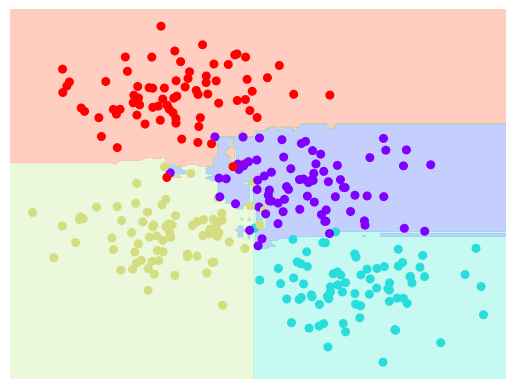

In [10]:
#RandomForestClassifier è un'implementazione ottimizzata che 
#gestisce automaticamente la randomizzazione. Ogni albero 
#nella foresta viene addestrato su un sottoinsieme di dati 
#selezionato con bootstrap (campionamento con reintroduzione) 
#e, ad ogni split, solo un sottoinsieme casuale delle feature 
#viene considerato. 
from sklearn.ensemble import RandomForestClassifier

# 100 alberi nella foresta
model_rf = RandomForestClassifier(n_estimators=100, random_state=0)
model_rf.fit(X, y) # Addestra il RandomForestClassifier
visualize_classifier(model_rf, X, y) 
# Funzione di utilità per visualizzare

<ErrorbarContainer object of 3 artists>

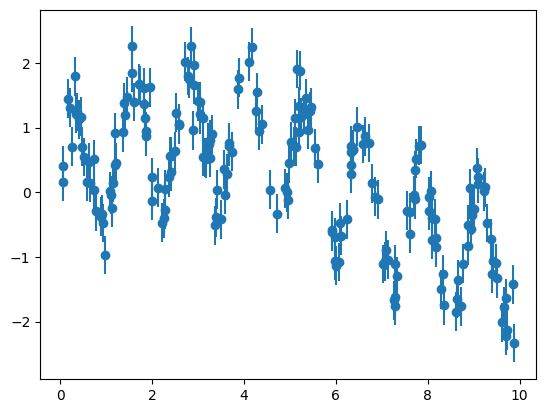

In [15]:
#Nella sezione precedente abbiamo considerato le 
#foreste casuali nel contesto della classificazione, 
#ma esse possono anche essere utilizzate nel caso di 
#regressione (ovvero di variabili continue anziché 
#categoriali). 
#Lo stimatore da utilizzare per questo caso è 
#RandomForestRegressor e la sintassi è molto simile a quanto 
#visto in precedenza.
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def model(x, sigma=0.3):
    fast_oscillation = np.sin(5 * x)
    slow_oscillation = np.sin(0.5 * x)
    noise = sigma * rng.randn(len(x))

    return slow_oscillation + fast_oscillation + noise

y = model(x)
plt.errorbar(x, y, 0.3, fmt='o')

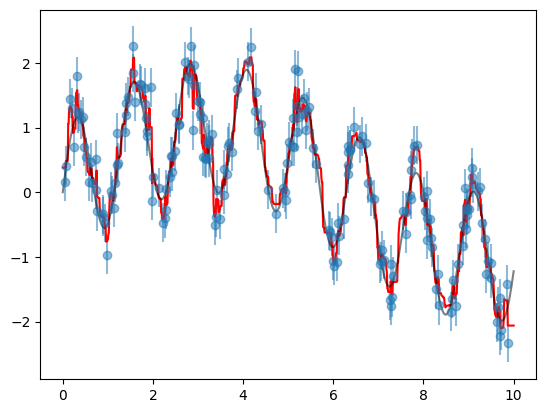

In [11]:
#Le Foreste Casuali possono essere utilizzate anche per 
#problemi di regressione (previsione di variabili continue) 
#tramite lo stimatore RandomForestRegressor. La sintassi è 
#simile, ma il modello prevede un valore numerico invece di 
#una classe.
from matplotlib import pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
# Dati generati per l'esempio di regressione
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)
def model_reg(x, sigma=0.3):
    fast_oscillation = np.sin(5 * x)
    slow_oscillation = np.sin(0.5 * x)
    noise = sigma * rng.randn(len(x))
    return slow_oscillation + fast_oscillation + noise
y_reg = model_reg(x)

forest_reg = RandomForestRegressor(200)
forest_reg.fit(x[:, None], y_reg) # Addestra il regressore

xfit = np.linspace(0, 10, 1000)
yfit = forest_reg.predict(xfit[:, None])
ytrue = model_reg(xfit, sigma=0)

# Codice per la visualizzazione del fit (plot)
plt.errorbar(x, y_reg, 0.3, fmt='o', alpha=0.5)
plt.plot(xfit, yfit, '-r')
plt.plot(xfit, ytrue, '-k', alpha=0.5)

In [17]:
#Il dataset digits contiene immagini 8x8 di cifre. 
#Le prime 64 immagini vengono visualizzate per 
#familiarizzare con i dati.
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys() # Per vedere le chiavi del dataset
# Codice per visualizzare le prime 64 cifre (omesso per brevità qui)

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [18]:
#I dati vengono divisi in set di training e test, 
#e il RandomForestClassifier viene addestrato con 
#1000 alberi.
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target, random_state=0)

model_digits = RandomForestClassifier(n_estimators=1000)
model_digits.fit(Xtrain, ytrain)
ypred = model_digits.predict(Xtest)

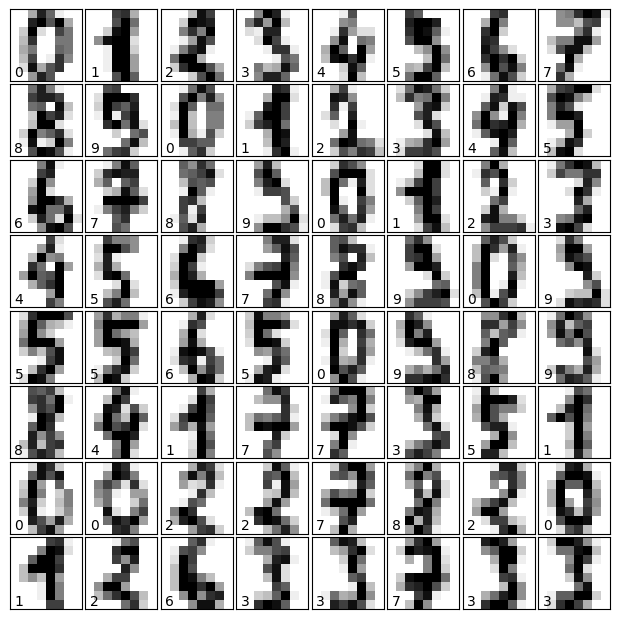

In [20]:
#Per ricordarci cosa stiamo guardando, 
#visualizzeremo i primi punti dati:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

In [21]:
#Possiamo classificare rapidamente le cifre 
#utilizzando una foresta casuale come segue:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target,
                                                random_state=0)
model = RandomForestClassifier(n_estimators=1000)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       1.00      0.98      0.99        44
           2       0.95      1.00      0.98        42
           3       0.98      0.96      0.97        46
           4       0.97      1.00      0.99        37
           5       0.96      0.98      0.97        47
           6       1.00      1.00      1.00        52
           7       1.00      0.98      0.99        49
           8       0.96      0.98      0.97        47
           9       0.98      0.96      0.97        48

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



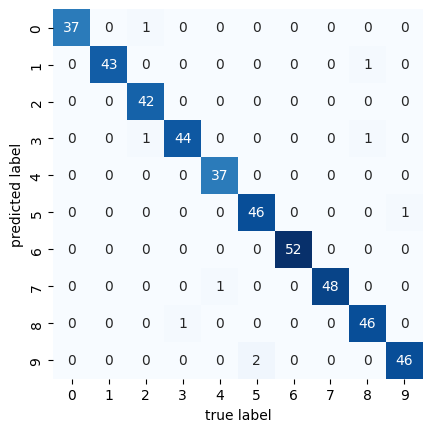

In [22]:
#Viene stampato il report di classificazione e la matrice 
#di confusione per valutare l'accuratezza del modello.
from sklearn import metrics
print(metrics.classification_report(ypred, ytest))

from sklearn.metrics import confusion_matrix
import seaborn as sns
mat = confusion_matrix(ytest, ypred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()